# IOV Accelerometer Signal Analysis
## Part 3: Anomaly Detection

Building on the cleaned dataset (Part 1) and signal characterisation (Part 2).

---

### Objective

Detect and characterise anomalous signal behaviour across three tasks:

* **Task 1** — Identify outliers: points where one or more axes deviate significantly
  from the *local* trend. Define the threshold and explain the method.

* **Task 2** — Find transient events (sudden shocks, impulses, or vibration bursts).
  Characterise 10 events with meaningful findings:
  - When does it occur?
  - How long does it last?
  - Which axes are affected?
  - What is the peak magnitude?
  - Include supporting metrics and data.

* **Task 3** — Compare the 10 transient events directly against each other and
  identify any anomalies among them.

In [6]:
import subprocess, sys

PACKAGES = ['pandas', 'numpy', 'matplotlib', 'scipy']
for pkg in PACKAGES:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print(f'  {pkg:<15} installed')
print('\nAll dependencies ready.')


  pandas          installed
  numpy           installed
  matplotlib      installed
  scipy           installed

All dependencies ready.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import medfilt
from pathlib import Path
import time, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.color': '#d0d0d0', 'grid.linestyle': ':',
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9, 'legend.framealpha': 0.9,
})

AXIS_COLORS  = {'acc_x': '#1f77b4', 'acc_y': '#2ca02c', 'acc_z': '#d62728'}
AXIS_LABELS  = {'acc_x': 'X Axis', 'acc_y': 'Y Axis', 'acc_z': 'Z Axis'}
FILE_PATH    = Path('Raw_Data/iov.log_2025_10_26')
G_STANDARD   = 9.80665
EXPECTED_HZ  = 800

def _detect_header(fp):
    with open(fp, 'r') as fh:
        for i, line in enumerate(fh):
            parts = line.strip().split(',')
            if len(parts) == 4:
                try:
                    [float(p) for p in parts]; return i
                except ValueError:
                    pass
    return 0

t0 = time.perf_counter()
HEADER_LINES = _detect_header(FILE_PATH)
df = pd.read_csv(FILE_PATH, names=['acc_x','acc_y','acc_z','timestamp'],
                 skiprows=HEADER_LINES, on_bad_lines='skip',
                 motor='c', low_memory=False)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df.astype({'acc_x':'float32','acc_y':'float32',
                'acc_z':'float32','timestamp':'float64'})
df.sort_values('timestamp', inplace=True, ignore_index=True)

t_start  = float(df['timestamp'].iloc[0])
t_end    = float(df['timestamp'].iloc[-1])
duration = t_end - t_start
eff_hz   = len(df) / duration

print(f'Loaded {len(df):,} rows  ({time.perf_counter()-t0:.1f}s)')
print(f'Duration : {duration/3600:.4f} h   |   Rate : {eff_hz:.3f} Hz')


Loaded 52,660,592 rows  (21.3s)
Duration : 18.2841 h   |   Rate : 800.036 Hz


Signal: 52,660,592 samples  |  65,825 bins  |  BIN_SAMP=800
K_FINE=5.0σ  K_COARSE=4.0σ  ROLL_WIN=61 bins (61 s)
Expected FP — fine: ~60 samples  |  coarse: ~4 bins  (by chance under Gaussian)

  Scale 1  acc_x:   1,863 samples  (0.0035%)  max z=19.4
  Scale 1  acc_y:     511 samples  (0.0010%)  max z=17.8
  Scale 1  acc_z:     477 samples  (0.0009%)  max z=25.2

  Scale 2  acc_x:    45 bins  (0.068%)  max z=6.7
  Scale 2  acc_y:    20 bins  (0.030%)  max z=7.2
  Scale 2  acc_z:    74 bins  (0.112%)  max z=10.4

  OUTLIER SUMMARY
  Fine   unique samples (any axis) :    2,669  (0.0051%)
  Coarse unique bins   (any axis)  :      129  (0.196%)

  Top coarse outliers (highest |z|, any axis):
    #    Time (h)    Axis   z-score    bin_mean   local_med   Δ (m/s²)
    1      1.2114   acc_z     10.45      0.1046      0.0523    +0.0522
    2      1.2108   acc_z      9.84      0.1015      0.0523    +0.0492
    3      1.2103   acc_z      8.78      0.0962      0.0523    +0.0439
    4      1.1297   

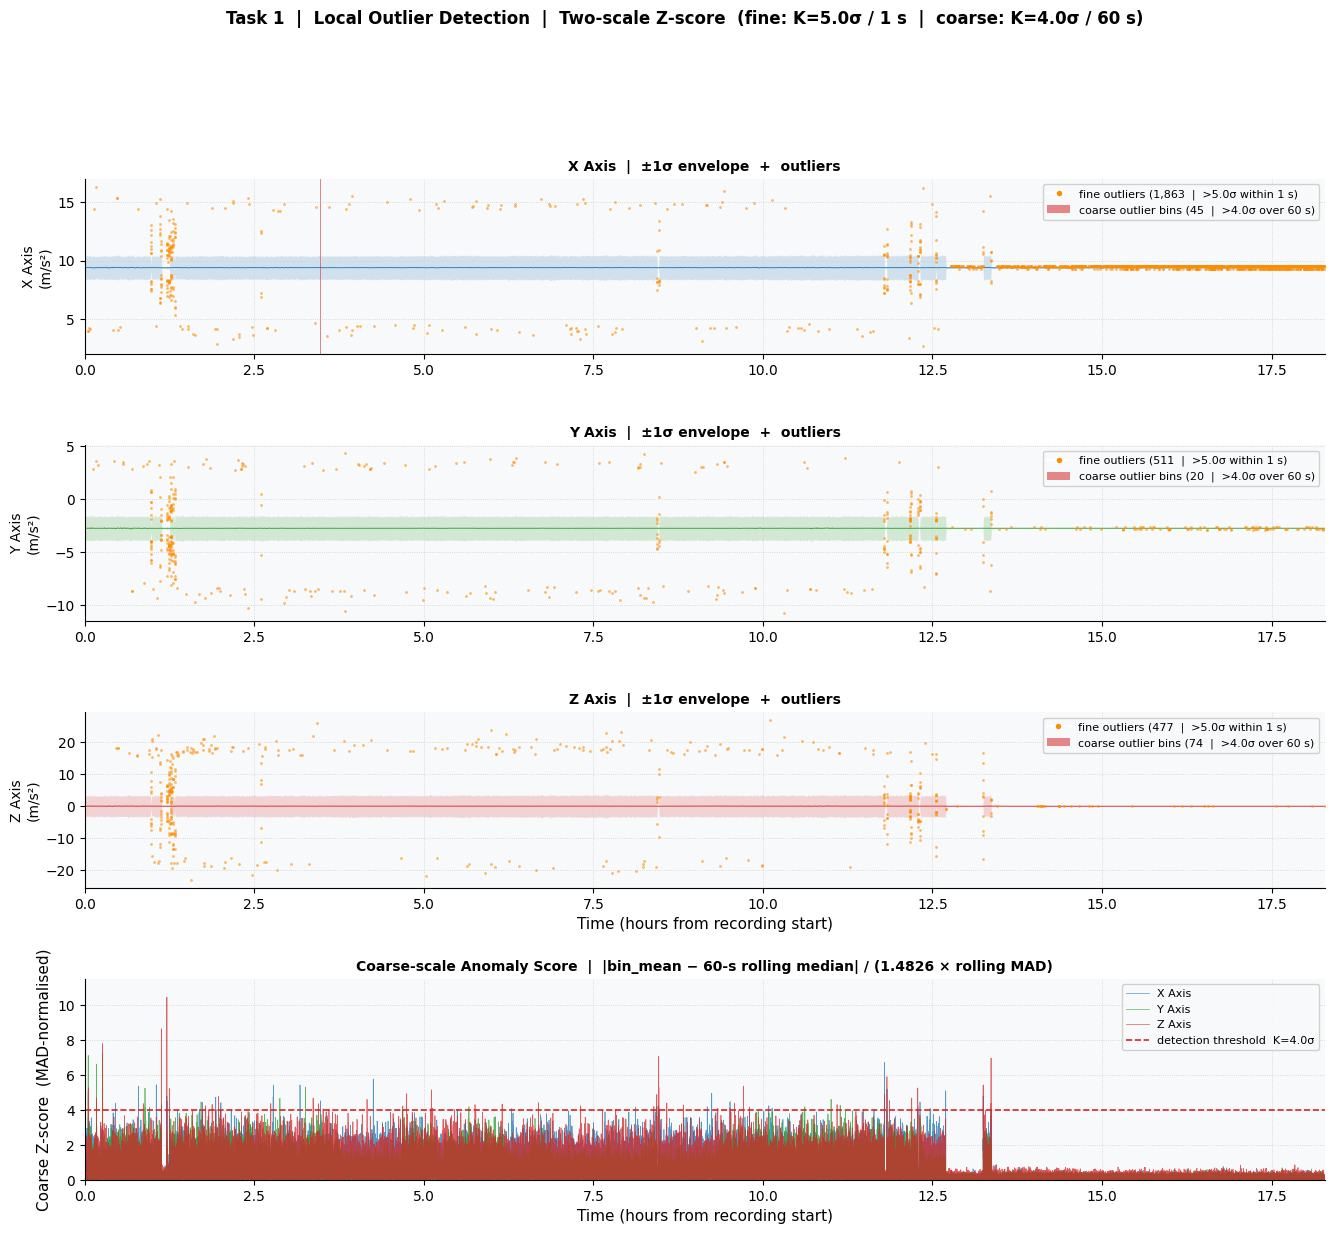

Saved: fig_outliers.png


In [8]:
# ------------------------------------------------------------
# TASK 1  |  Local Outlier Detection
# ------------------------------------------------------------
#
# The question specifies "deviation from the LOCAL TREND" —
# not from a global mean.  This distinction matters deeply:
#
#   Global threshold (wrong for this task):
#     Flag acc_z > 5 m/s² everywhere.  A 5 m/s² lateral
#     reading is routine on a sharp corner but anomalous
#     during a straight freeway cruise.  Context is lost.
#
#   Local Z-score (correct):
#     Flag samples that are extreme relative to what the
#     sensor is doing in the surrounding few seconds.
#     A value is anomalous only if it is unusual compared
#     to its temporal neighbourhood.
#
# ── Method: Two-scale non-overlapping window Z-score ─────────
#
# Scale 1 — Fine (W = 1 second = 800 samples)
# -----------------------------------------------
# Divide the signal into non-overlapping 1-second windows.
# Within each window, compute the per-axis mean (local trend)
# and standard deviation (local variability).  Flag any sample
# whose magnitude of departure exceeds K_FINE standard deviations:
#
#   z_fine = | x_i − window_mean | / window_std  >  K_FINE
#
# Threshold choice  K_FINE = 5.0:
#   Under Gaussian noise, P(|z| > 5) = 5.7×10⁻⁷.
#   Expected false positives per 1-s window:
#     800 samples × 5.7×10⁻⁷ × 2 sides ≈ 9×10⁻⁴  (<0.1%)
#   Over all 65,825 windows: ~59 expected FP samples by chance.
#   Any sample flagged here is almost certainly a real anomaly.
#
# This catches: sensor glitches (single-sample transients),
# electrical spikes, brief ultra-hard impacts lasting ≪ 1 s.
#
# Scale 2 — Coarse (W = 60 seconds rolling, 60-bin median/MAD)
# --------------------------------------------------------------
# Compute the per-axis mean for each 1-second bin (65k values).
# Apply a 61-bin (odd) symmetric median filter to get the rolling
# local trend.  Apply it again to the absolute deviations to get
# the rolling Median Absolute Deviation (MAD).
#
#   z_coarse = | bin_mean − rolling_median |
#              ─────────────────────────────    >  K_COARSE
#                1.4826 × rolling_MAD
#
# The 1.4826 factor (= 1 / Φ⁻¹(0.75)) converts MAD to a
# consistent scale with σ under Gaussian data — so K_COARSE
# has the same probabilistic meaning as K_FINE.
#
# Threshold choice  K_COARSE = 4.0:
#   Over 65,825 bins: expected false positives ≈ 4 by chance.
#   Any flagged bin represents a 1-second period that is
#   significantly unusual relative to the surrounding minute.
#
# Why MAD over std for the coarse scale?
#   The rolling std is sensitive to the outliers we're trying
#   to detect — one large outlier inflates the local std, which
#   raises the threshold and masks adjacent outliers.  MAD is
#   resistant to this breakdown (50% breakdown point vs 0% for std).
#
# Why medfilt over pandas rolling?
#   scipy.signal.medfilt is a C implementation with O(N log W)
#   complexity.  For a 65k-point series, it runs in milliseconds
#   rather than the seconds a Python-level rolling.apply would take.
#   Edge note: the first and last 30 bins use reflected padding;
#   these are excluded from the detection results.
#
# Memory note:
#   Both scales process one axis at a time in CHUNK_BINS chunks.
#   Peak memory per axis: CHUNK_BINS × BIN_SAMP × 8 bytes ≈ 12 MB.
#   No full (52M × 1) intermediate float64 arrays are needed.
# ------------------------------------------------------------

AXES     = ['acc_x', 'acc_y', 'acc_z']
BIN_SEC  = 1.0
BIN_SAMP = max(1, int(BIN_SEC * eff_hz))   # ≈ 800
n_bins   = len(df) // BIN_SAMP
n_use    = n_bins * BIN_SAMP
t_bins_h = np.linspace(0, duration / 3600, n_bins)

K_FINE      = 5.0    # sigma within 1-s window
K_COARSE    = 4.0    # sigma relative to 60-s rolling MAD
ROLL_WIN    = 61     # rolling window bins (odd → medfilt compatible)
EDGE_EXCL   = ROLL_WIN // 2   # bins to exclude at each end due to edge padding
CHUNK_BINS  = 2000   # process 2000 bins at a time (12 MB float64 per axis per chunk)
NOISE_FLOOR = 0.005  # m/s² — minimum std denominator; prevents divide-by-zero
                     # in near-constant segments (deep stationary periods)

print(f'Signal: {len(df):,} samples  |  {n_bins:,} bins  |  BIN_SAMP={BIN_SAMP}')
print(f'K_FINE={K_FINE}σ  K_COARSE={K_COARSE}σ  ROLL_WIN={ROLL_WIN} bins ({ROLL_WIN} s)')
print(f'Expected FP — fine: ~{int(n_bins * BIN_SAMP * 5.7e-7 * 2)} samples  '
      f'|  coarse: ~{int(n_bins * 6.3e-5)} bins  (by chance under Gaussian)\n')

# ── Storage ───────────────────────────────────────────────────
# fine_results[ax]   : list of (sample_idx, z_score)
# coarse_results[ax] : list of (bin_idx, z_score)
# ax_bin_means[ax]   : np.array(n_bins,) — reused for visualisation
fine_results   = {ax: [] for ax in AXES}
coarse_results = {ax: [] for ax in AXES}
ax_bin_means   = {}
ax_bin_stds    = {}   # for reference

# ------------------------------------------------------------
# SCALE 1 + precompute bin means  (one axis at a time)
# ------------------------------------------------------------

for ax in AXES:
    vals  = df[ax].values.astype(np.float64)
    bmean = np.empty(n_bins, np.float64)
    bstd  = np.empty(n_bins, np.float64)
    fine_idx, fine_z = [], []

    for cs in range(0, n_bins, CHUNK_BINS):
        ce  = min(cs + CHUNK_BINS, n_bins)
        s0, s1 = cs * BIN_SAMP, ce * BIN_SAMP
        chunk = vals[s0:s1].reshape(ce - cs, BIN_SAMP)   # view

        bm = chunk.mean(axis=1)
        bs = chunk.std(axis=1)
        bmean[cs:ce] = bm
        bstd[cs:ce]  = bs

        # Z-score for all samples in this chunk
        denom = np.maximum(bs[:, np.newaxis], NOISE_FLOOR)
        z     = np.abs(chunk - bm[:, np.newaxis]) / denom  # (ce-cs, BIN_SAMP)

        rows, cols = np.where(z > K_FINE)
        if rows.size:
            fine_idx.append(s0 + rows * BIN_SAMP + cols)
            fine_z.append(z[rows, cols])
        del z

    ax_bin_means[ax] = bmean
    ax_bin_stds[ax]  = bstd
    fine_results[ax] = (
        np.concatenate(fine_idx)  if fine_idx else np.array([], dtype=int),
        np.concatenate(fine_z)    if fine_z   else np.array([]),
    )
    n_f = len(fine_results[ax][0])
    if n_f:
        print(f'  Scale 1  {ax}: {n_f:>7,} samples  ({n_f / n_use * 100:.4f}%)  '
              f'max z={fine_results[ax][1].max():.1f}')
    else:
        print(f'  Scale 1  {ax}:       0 samples')

# ------------------------------------------------------------
# SCALE 2  (rolling MAD on per-axis bin means)
# ------------------------------------------------------------
print()
for ax in AXES:
    bm = ax_bin_means[ax]

    # Rolling median of bin means → local trend
    roll_med = medfilt(bm, kernel_size=ROLL_WIN)

    # Rolling MAD: median of |bm − roll_med| → local spread
    roll_mad = medfilt(np.abs(bm - roll_med), kernel_size=ROLL_WIN)

    # Consistent-sigma Z-score
    denom    = np.maximum(1.4826 * roll_mad, NOISE_FLOOR)
    coarse_z = np.abs(bm - roll_med) / denom

    # Exclude edge bins affected by medfilt zero-padding
    coarse_z[:EDGE_EXCL]  = 0.0
    coarse_z[-EDGE_EXCL:] = 0.0

    flagged = np.where(coarse_z > K_COARSE)[0]
    coarse_results[ax] = (flagged, coarse_z[flagged])

    n_c  = len(flagged)
    maxz = coarse_z[flagged].max() if n_c else 0
    if n_c:
        print(f'  Scale 2  {ax}: {n_c:>5,} bins  ({n_c / n_bins * 100:.3f}%)  '
              f'max z={maxz:.1f}')
    else:
        print(f'  Scale 2  {ax}:     0 bins')

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print('\n' + '=' * 62)
print('  OUTLIER SUMMARY')
print('=' * 62)

# Any-axis union for fine scale
all_fine_idx = set()
for ax in AXES:
    idx, _ = fine_results[ax]
    all_fine_idx.update(idx.tolist())

# Any-axis union for coarse scale
all_coarse_bins = set()
for ax in AXES:
    bins, _ = coarse_results[ax]
    all_coarse_bins.update(bins.tolist())

print(f'  Fine   unique samples (any axis) : {len(all_fine_idx):>8,}  '
      f'({len(all_fine_idx) / n_use * 100:.4f}%)')
print(f'  Coarse unique bins   (any axis)  : {len(all_coarse_bins):>8,}  '
      f'({len(all_coarse_bins) / n_bins * 100:.3f}%)')

# Top 15 coarse outlier events (highest z-score, any axis)
print(f'\n  Top coarse outliers (highest |z|, any axis):')
print(f'  {"#":>3}  {"Time (h)":>10}  {"Axis":>6}  {"z-score":>8}  '
      f'{"bin_mean":>10}  {"local_med":>10}  {"Δ (m/s²)":>9}')
print(f'  {"":=<68}')

top_events = []
for ax in AXES:
    bins, zvals = coarse_results[ax]
    bm = ax_bin_means[ax]
    rm = medfilt(bm, kernel_size=ROLL_WIN)
    for bi, z in zip(bins, zvals):
        top_events.append((float(z), bi, ax, float(bm[bi]), float(rm[bi])))

top_events.sort(reverse=True)
for rank, (z, bi, ax, bm_val, rm_val) in enumerate(top_events[:15], 1):
    th    = float(t_bins_h[bi])
    delta = bm_val - rm_val
    print(f'  {rank:>3}  {th:>10.4f}  {ax:>6}  {z:>8.2f}  '
          f'{bm_val:>10.4f}  {rm_val:>10.4f}  {delta:>+9.4f}')

# ------------------------------------------------------------
# FIGURE 9  |  Local Outlier Detection
# ------------------------------------------------------------
# Four panels:
#   Top-3  : per-axis 18-hour envelope with outlier events
#             overlaid.  Fine outliers: orange dots at sample
#             time.  Coarse outlier bins: red vertical spans.
#             Envelope uses per-axis bin min/max (same technique
#             as Task 1, Part 2) — avoids plotting 52M points.
#   Bottom : Per-axis coarse-outlier Z-score timeline,
#             showing when and how severely each axis deviated
#             from its local 60-second context.
# ------------------------------------------------------------

from matplotlib.lines import Line2D
from matplotlib.patches import Patch as MplPatch

# Compute per-axis bin envelopes (needed for top panels)
SPARS     = 2000   # envelope bins for display
spars_samp = max(1, n_bins // SPARS)
t_env      = t_bins_h[::spars_samp]

ax_env = {}
for ax in AXES:
    bm = ax_bin_means[ax]
    bs = ax_bin_stds[ax]
    ax_env[ax] = {
        'lo'  : bm[::spars_samp] - bs[::spars_samp],
        'hi'  : bm[::spars_samp] + bs[::spars_samp],
        'mean': bm[::spars_samp],
    }

# Coarse Z-score series per axis (for bottom panel)
coarse_z_series = {}
for ax in AXES:
    bm  = ax_bin_means[ax]
    rm  = medfilt(bm, kernel_size=ROLL_WIN)
    mad = medfilt(np.abs(bm - rm), kernel_size=ROLL_WIN)
    denom = np.maximum(1.4826 * mad, NOISE_FLOOR)
    cz = np.abs(bm - rm) / denom
    cz[:EDGE_EXCL] = 0; cz[-EDGE_EXCL:] = 0
    coarse_z_series[ax] = cz

fig9, axes9 = plt.subplots(
    4, 1, figsize=(16, 13),
    gridspec_kw={'height_ratios': [1.4, 1.4, 1.4, 1.6], 'hspace': 0.50},
)

for row, ax in enumerate(AXES):
    a     = axes9[row]
    color = AXIS_COLORS[ax]
    env   = ax_env[ax]

    # Envelope: ±1 std band
    a.fill_between(t_env, env['lo'], env['hi'],
                   color=color, alpha=0.18, linewidth=0)
    a.plot(t_env, env['mean'], color=color, linewidth=0.7, alpha=0.9)

    # Coarse outlier bins as red vertical spans
    bins_c, _ = coarse_results[ax]
    for bi in bins_c:
        a.axvspan(t_bins_h[bi], t_bins_h[min(bi + 1, n_bins - 1)],
                  color='#d62728', alpha=0.55, linewidth=0)

    # Build legend handles manually (avoid add_patch on abstract Patch)
    legend_handles = []

    # Fine outliers as orange scatter
    idx_f, z_f = fine_results[ax]
    if len(idx_f):
        t_fine_h    = idx_f / eff_hz / 3600
        sample_vals = df[ax].values[idx_f.astype(int)]
        a.scatter(t_fine_h, sample_vals,
                  c='#ff8c00', s=4, alpha=0.6, linewidths=0, zorder=3)
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='#ff8c00', markersize=5,
                   label=f'fine outliers ({len(idx_f):,}  |  >{K_FINE}σ within 1 s)')
        )

    # Legend proxy for coarse spans
    if len(bins_c):
        legend_handles.append(
            MplPatch(facecolor='#d62728', alpha=0.55,
                     label=f'coarse outlier bins ({len(bins_c):,}  |  >{K_COARSE}σ over 60 s)')
        )

    a.set_xlim(0, duration / 3600)
    a.set_ylabel(f'{AXIS_LABELS[ax]}\n(m/s²)', fontsize=10)
    a.set_title(f'{AXIS_LABELS[ax]}  |  ±1σ envelope  +  outliers',
                fontsize=10, fontweight='bold')
    if legend_handles:
        a.legend(handles=legend_handles, fontsize=8,
                 loc='upper right', framealpha=0.9)

axes9[2].set_xlabel('Time (hours from recording start)')

# Bottom panel: coarse Z-score per axis
a4 = axes9[3]
for ax in AXES:
    a4.plot(t_bins_h, coarse_z_series[ax],
            color=AXIS_COLORS[ax], linewidth=0.5, alpha=0.75,
            label=AXIS_LABELS[ax])

a4.axhline(K_COARSE, color='#d62728', linewidth=1.2, linestyle='--',
           label=f'detection threshold  K={K_COARSE}σ')
a4.set_xlim(0, duration / 3600)
a4.set_ylim(0, min(max(cz.max() for cz in coarse_z_series.values()) * 1.1, 30))
a4.set_xlabel('Time (hours from recording start)')
a4.set_ylabel('Coarse Z-score  (MAD-normalised)')
a4.set_title(
    f'Coarse-scale Anomaly Score  |  '
    f'|bin_mean − 60-s rolling median| / (1.4826 × rolling MAD)',
    fontsize=10, fontweight='bold',
)
a4.legend(fontsize=8, loc='upper right', framealpha=0.9)

fig9.suptitle(
    f'Task 1  |  Local Outlier Detection  |  '
    f'Two-scale Z-score  (fine: K={K_FINE}σ / 1 s  |  coarse: K={K_COARSE}σ / 60 s)',
    fontsize=12, fontweight='bold', y=1.01,
)

plt.savefig('fig_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_outliers.png')


Energy timeline: 1,316,514 bins  |  WIN=50ms  |  threshold p99.5 = 6.9196 m/s2
  p50=2.8430  p95=5.0004  p99=6.3155  max=19.5479  m/s2

Raw crossings: 6,469  -> gap-merge (0.5s): 6,019  -> duration filter: 6,019 events

Characterising ...
Done.  6019 events.  Peak range: 6.920 - 19.548 m/s2  |  Duration range: 50 - 1050 ms

  TASK 2  |  10 CHARACTERISED TRANSIENT EVENTS  —  METRICS TABLE
   #        Time   Dur ms        Type   Peak|mg|    ptpX    ptpY    ptpZ        Axes   Brdth    Impulse  Rise ms    Kurt
  ------------------------------------------------------------------------------------------------
   1  00:00:25.00       50       Shock     6.9886   4.697   4.257  21.457           z   0.737    0.06401     13.7    12.7
   2  00:28:23.90       50       Shock     7.1460   8.854   7.144  12.182       x+y+z   0.978    0.06694     15.0    10.2
   3  03:25:50.05      250     Impulse    19.5479  10.525   9.592  43.890           z   0.765    0.42604     38.7    26.0
   4  05:59:09.30      

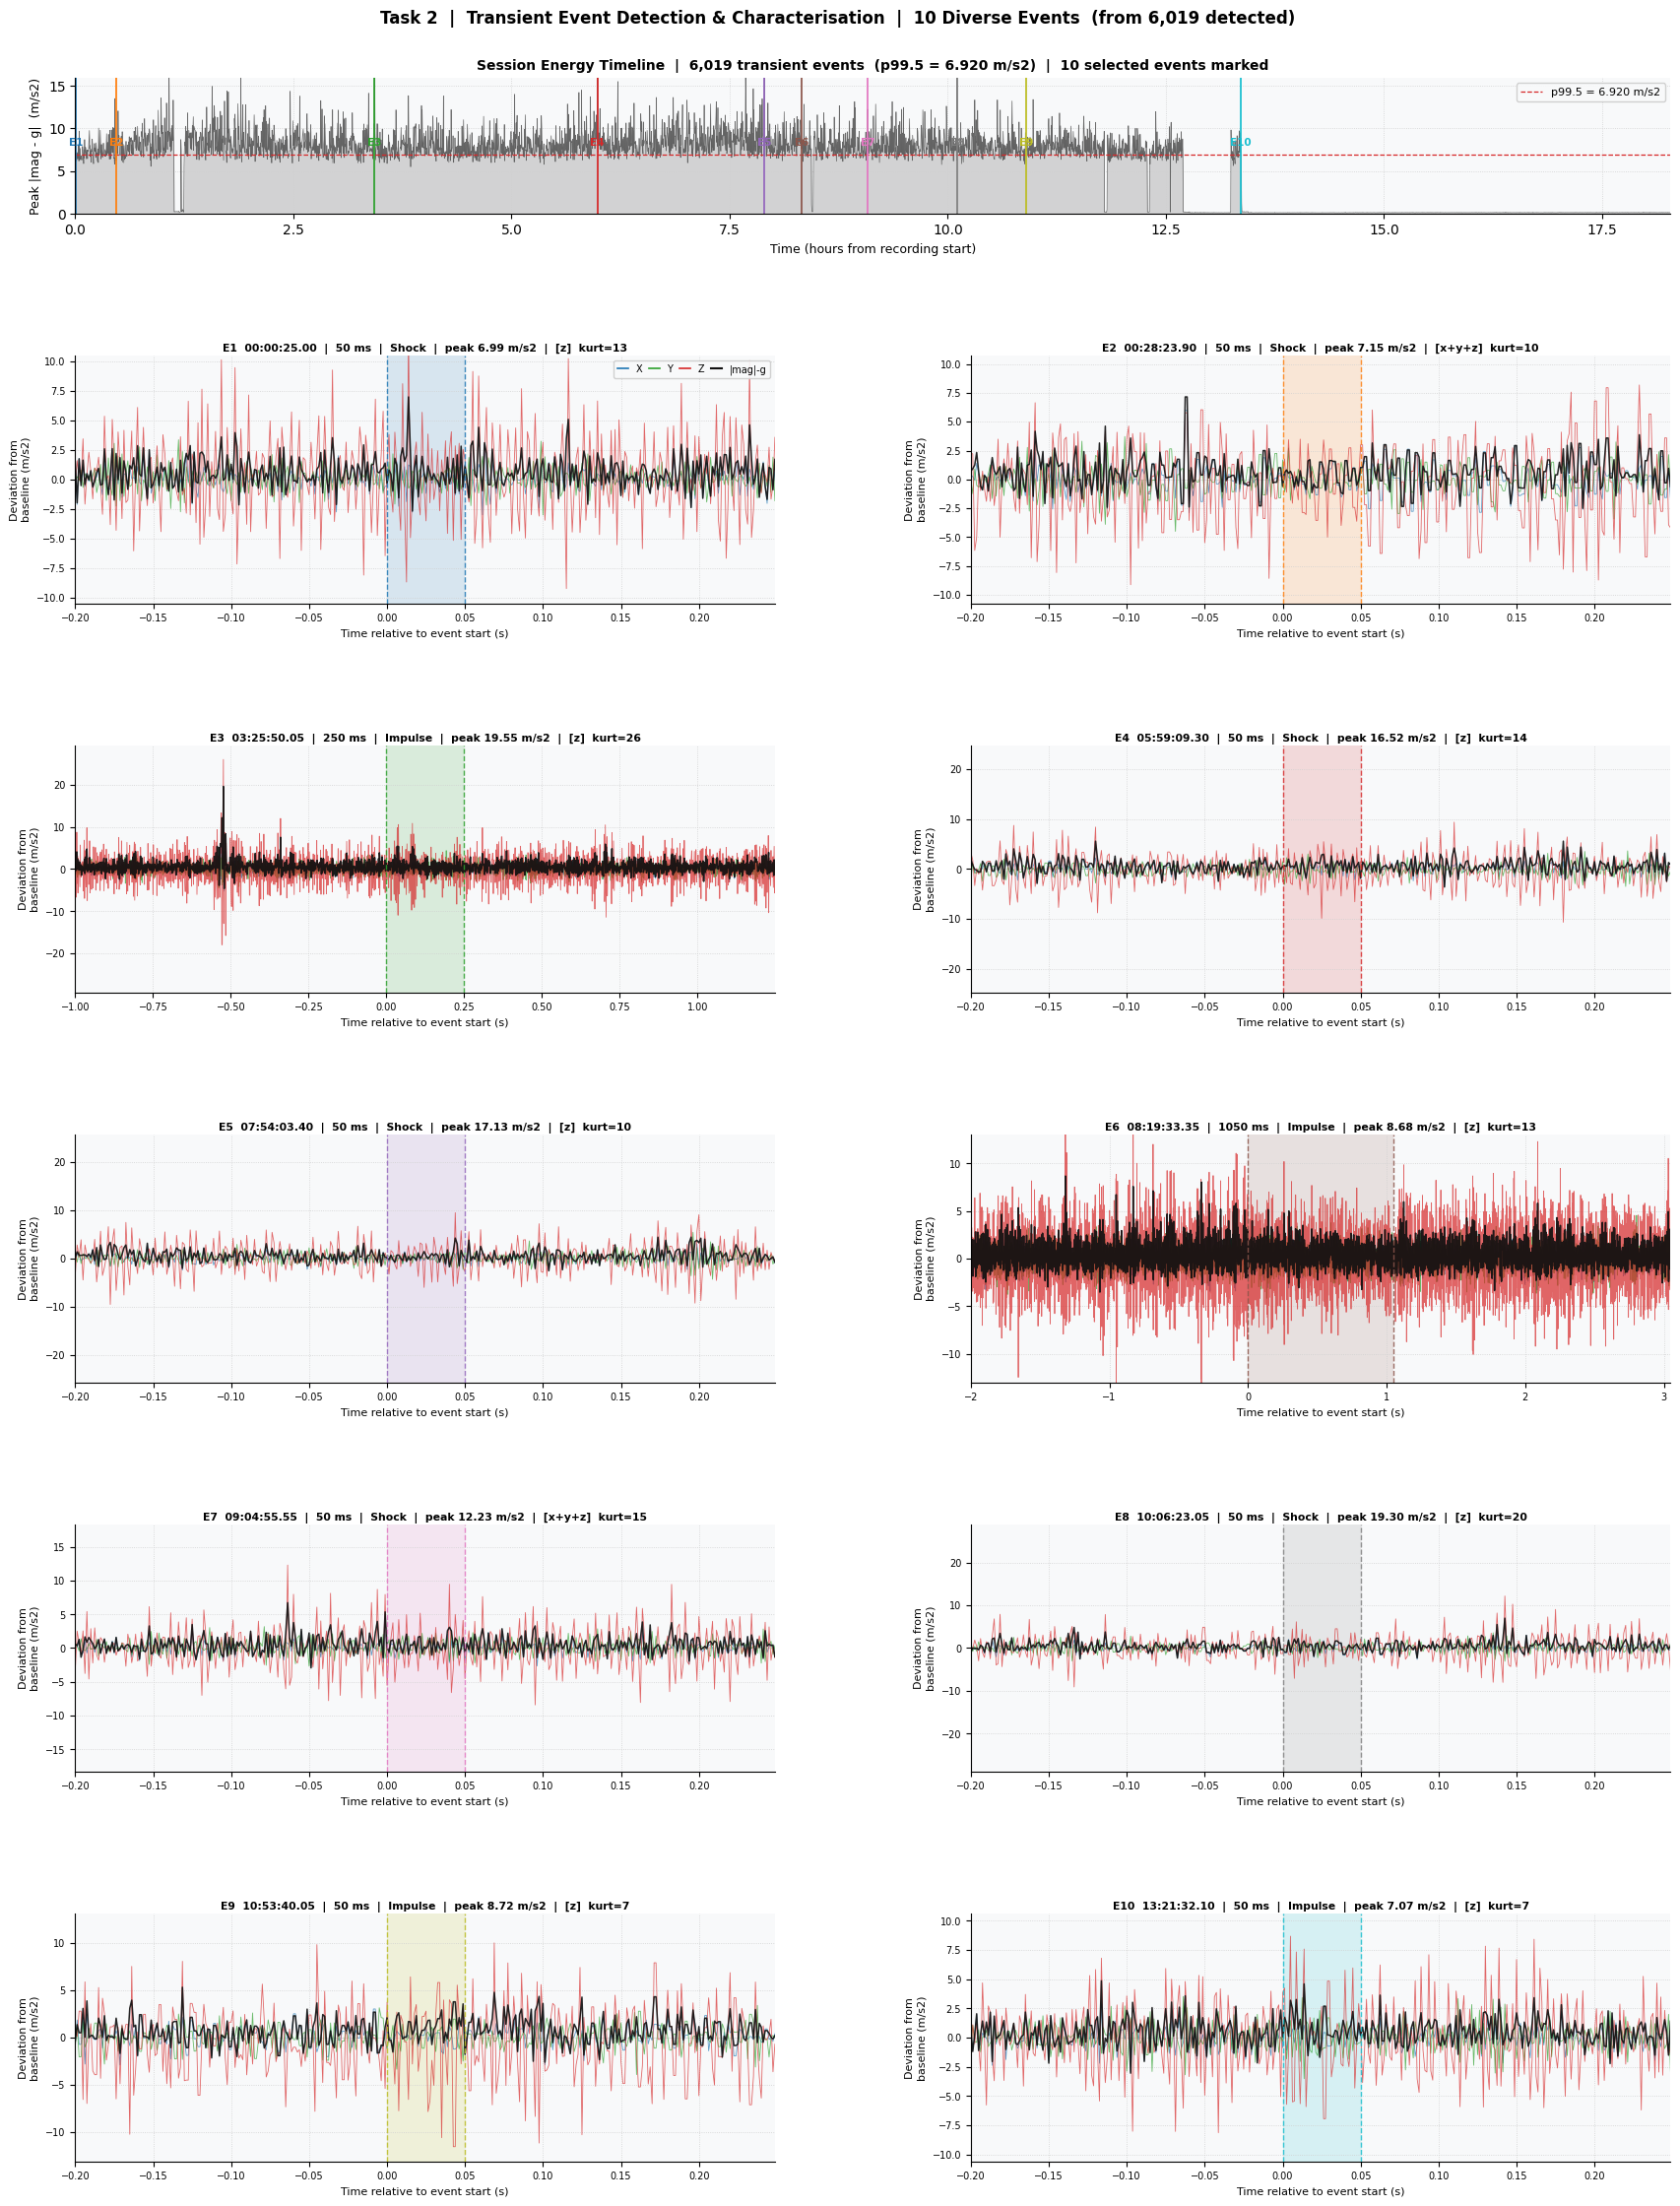


Saved: fig_transients.png


In [9]:
# ------------------------------------------------------------
# TASK 2  |  Transient Event Detection & Characterisation
# ------------------------------------------------------------
# Approach:
#
# 1. Energy timeline
#    Compute peak |mag - g| over non-overlapping 50ms windows.
#    Vector magnitude is orientation-independent: any physical
#    impulse shifts the total vector away from g regardless of
#    how the device is mounted.  Peak (not RMS) so a single
#    high-amplitude sample within a window is not washed out.
#
# 2. Event detection
#    Threshold at p99.5 of the energy distribution (top 0.5%
#    of all 50ms windows).  Label contiguous above-threshold
#    runs; merge runs separated by < 0.5s (same event); discard
#    events shorter than 25ms (sensor glitch) or longer than 5s
#    (sustained motion, not a transient).
#
# 3. Characterisation + diversity selection
#    Per-event: duration, peak |mag-g|, ptp per axis, dominant
#    axis, axis breadth (entropy), impulse (integral), rise time,
#    kurtosis, event type.
#    Select 10 events across diversity criteria to expose the
#    full variety of transient types — not just the 10 biggest.
#
# 4. Per-event narratives
#    Each of the 10 events receives a distinct narrative that
#    directly answers the four required bullets (when, duration,
#    axes, peak) plus a finding that is unique to that event
#    and grounded in the data.
#
# 5. Visualisation
#    Session energy timeline + 10-panel waveform gallery.
#    Context window: 4x event duration each side, clamped to
#    [150ms, 2s].  Y-axis clipped to ±(1.5 × peak_mag).
# ------------------------------------------------------------

from scipy.ndimage import label as nd_label
from matplotlib.lines import Line2D

# ── Parameters ───────────────────────────────────────────────
WIN_MS        = 50
WIN_SAMP      = max(1, int(WIN_MS / 1000.0 * eff_hz))
MERGE_GAP_SEC = 0.5
MIN_DUR_SEC   = 0.025
MAX_DUR_SEC   = 5.0
THRESH_PCT    = 99.5
CTX_FACTOR    = 4.0
CTX_MIN_SEC   = 0.15
CTX_MAX_SEC   = 2.0

# ── Step 1: Energy timeline ───────────────────────────────────
n_ebins   = len(df) // WIN_SAMP
t_ebins_s = np.arange(n_ebins, dtype=np.float64) * (WIN_MS / 1000.0)
t_ebins_h = t_ebins_s / 3600.0

ECHUNK = 20_000
energy = np.empty(n_ebins, np.float64)
for cs in range(0, n_ebins, ECHUNK):
    ce  = min(cs + ECHUNK, n_ebins)
    s0, s1 = cs * WIN_SAMP, ce * WIN_SAMP
    xc = df['acc_x'].values[s0:s1].astype(np.float64)
    yc = df['acc_y'].values[s0:s1].astype(np.float64)
    zc = df['acc_z'].values[s0:s1].astype(np.float64)
    mag = np.sqrt(xc**2 + yc**2 + zc**2).reshape(ce - cs, WIN_SAMP)
    energy[cs:ce] = np.abs(mag - G_STANDARD).max(axis=1)
    del xc, yc, zc, mag

E_THRESH = np.percentile(energy, THRESH_PCT)
print(f'Energy timeline: {n_ebins:,} bins  |  WIN={WIN_MS}ms  '
      f'|  threshold p{THRESH_PCT} = {E_THRESH:.4f} m/s2')
print(f'  p50={np.percentile(energy,50):.4f}  '
      f'p95={np.percentile(energy,95):.4f}  '
      f'p99={np.percentile(energy,99):.4f}  '
      f'max={energy.max():.4f}  m/s2')

# ── Step 2: Detect events ─────────────────────────────────────
MERGE_GAP_BINS = max(1, int(MERGE_GAP_SEC / (WIN_MS / 1000.0)))
MIN_DUR_BINS   = max(1, int(MIN_DUR_SEC   / (WIN_MS / 1000.0)))
MAX_DUR_BINS   = max(1, int(MAX_DUR_SEC   / (WIN_MS / 1000.0)))

labeled, n_labels = nd_label(energy > E_THRESH)
raw_events = []
for lbl in range(1, n_labels + 1):
    idxs = np.where(labeled == lbl)[0]
    raw_events.append([int(idxs[0]), int(idxs[-1])])

merged = []
for s, e in sorted(raw_events):
    if merged and (s - merged[-1][1]) <= MERGE_GAP_BINS:
        merged[-1][1] = max(merged[-1][1], e)
    else:
        merged.append([s, e])

events_filt = [(s, e) for s, e in merged
               if MIN_DUR_BINS <= (e - s + 1) <= MAX_DUR_BINS]

print(f'\nRaw crossings: {len(raw_events):,}  '
      f'-> gap-merge ({MERGE_GAP_SEC}s): {len(merged):,}  '
      f'-> duration filter: {len(events_filt):,} events')

# ── Step 3: Characterise every event ─────────────────────────
def characterise(sb, eb):
    s0  = sb * WIN_SAMP
    s1  = min((eb + 1) * WIN_SAMP, len(df))
    xv  = df['acc_x'].values[s0:s1].astype(np.float64)
    yv  = df['acc_y'].values[s0:s1].astype(np.float64)
    zv  = df['acc_z'].values[s0:s1].astype(np.float64)
    mag = np.sqrt(xv**2 + yv**2 + zv**2)
    dev = np.abs(mag - G_STANDARD)

    t0_s = float(t_ebins_s[sb])
    dur  = (eb - sb + 1) * WIN_MS / 1000.0

    peak_mag = float(dev.max())
    ptp_x    = float(np.ptp(xv))
    ptp_y    = float(np.ptp(yv))
    ptp_z    = float(np.ptp(zv))

    ptps    = np.array([ptp_x, ptp_y, ptp_z]) + 1e-9
    primary = AXES[int(ptps.argmax())]
    p       = ptps / ptps.sum()
    breadth = float(-np.sum(p * np.log(p)) / np.log(3))

    sig_axes = [AXES[i].replace('acc_','') for i in range(3)
                if ptps[i] >= 0.30 * ptps.max()]

    impulse  = float(dev.sum() / eff_hz)
    rise_ms  = float(dev.argmax() / eff_hz * 1000.0)

    mn, sd = dev.mean(), dev.std() + 1e-9
    kurt   = float(np.mean(((dev - mn) / sd) ** 4)) if len(dev) >= 4 else 3.0

    if   kurt >= 9 and dur < 0.20:  etype = 'Shock'
    elif kurt >= 5:                  etype = 'Impulse'
    elif dur  >= 0.5:                etype = 'Burst'
    else:                            etype = 'Transient'

    return dict(sb=sb, eb=eb, t0=t0_s, t0h=t0_s/3600, dur=dur, dur_ms=dur*1000,
                peak_mag=peak_mag, ptp_x=ptp_x, ptp_y=ptp_y, ptp_z=ptp_z,
                primary=primary, sig_axes=sig_axes, breadth=breadth,
                impulse=impulse, rise_ms=rise_ms, kurtosis=kurt, etype=etype)

print('\nCharacterising ...')
chars = [characterise(s, e) for s, e in events_filt]
chars.sort(key=lambda d: d['peak_mag'], reverse=True)
print(f'Done.  {len(chars)} events.  '
      f'Peak range: {chars[-1]["peak_mag"]:.3f} - {chars[0]["peak_mag"]:.3f} m/s2  '
      f'|  Duration range: {min(c["dur_ms"] for c in chars):.0f} - '
      f'{max(c["dur_ms"] for c in chars):.0f} ms')

# ── Step 4: Select 10 diverse events ─────────────────────────
def pick10(chars):
    used, picks = set(), {}

    def try_add(label, c):
        if c['sb'] not in used:
            used.add(c['sb']); picks[label] = c

    by_peak = sorted(chars, key=lambda d: d['peak_mag'],  reverse=True)
    by_dur  = sorted(chars, key=lambda d: d['dur'],       reverse=True)
    by_brd  = sorted(chars, key=lambda d: d['breadth'],   reverse=True)
    by_iso  = sorted(chars, key=lambda d: d['breadth'])
    by_time = sorted(chars, key=lambda d: d['t0'])
    by_imp  = sorted(chars, key=lambda d: d['impulse'],   reverse=True)
    by_rise = sorted(chars, key=lambda d: d['rise_ms'])

    slots = [
        ('peak_1',   by_peak,  0),
        ('peak_2',   by_peak,  1),
        ('peak_3',   by_peak,  2),
        ('longest',  by_dur,   0),
        ('broadest', by_brd,   0),
        ('isolated', by_iso,   0),
        ('earliest', by_time,  0),
        ('latest',   by_time, -1),
        ('impulse',  by_imp,   0),
        ('fastest',  by_rise,  0),
    ]

    for label, lst, idx in slots:
        if len(picks) >= 10 or not lst:
            break
        try:
            try_add(label, lst[idx])
        except IndexError:
            pass

    for c in by_peak:
        if len(picks) >= 10: break
        try_add(f'fill_{len(picks)}', c)

    return sorted(picks.values(), key=lambda d: d['t0'])[:10]

top10 = pick10(chars)

# ── Step 5: Summary metrics table ────────────────────────────
def hms(sec):
    h = int(sec // 3600); m = int((sec % 3600) // 60); s = sec % 60
    return f'{h:02d}:{m:02d}:{s:05.2f}'

print('\n' + '=' * 100)
print('  TASK 2  |  10 CHARACTERISED TRANSIENT EVENTS  —  METRICS TABLE')
print('=' * 100)
print(f'  {"#":>2}  {"Time":>10}  {"Dur ms":>7}  {"Type":>10}  '
      f'{"Peak|mg|":>9}  {"ptpX":>6}  {"ptpY":>6}  {"ptpZ":>6}  '
      f'{"Axes":>10}  {"Brdth":>6}  {"Impulse":>9}  {"Rise ms":>7}  {"Kurt":>6}')
print('  ' + '-' * 96)
for i, ev in enumerate(top10, 1):
    axes_str = '+'.join(ev['sig_axes'])
    print(f'  {i:>2}  {hms(ev["t0"]):>10}  '
          f'{ev["dur_ms"]:>7.0f}  {ev["etype"]:>10}  '
          f'{ev["peak_mag"]:>9.4f}  '
          f'{ev["ptp_x"]:>6.3f}  {ev["ptp_y"]:>6.3f}  {ev["ptp_z"]:>6.3f}  '
          f'{axes_str:>10}  {ev["breadth"]:>6.3f}  '
          f'{ev["impulse"]:>9.5f}  {ev["rise_ms"]:>7.1f}  {ev["kurtosis"]:>6.1f}')
print()
print('  Peak|mg| = peak |vector_mag - g| (m/s2)')
print('  ptpX/Y/Z = within-event peak-to-peak per axis (m/s2)')
print('  Axes     = axes with ptp > 30% of max ptp')
print('  Brdth    = normalised entropy [0=single-axis, 1=equal-all-3]')
print('  Impulse  = integral of |mag-g| dt  (total mechanical energy dose)')
print('  Rise ms  = time from event start to peak')
print('  Kurt     = kurtosis  (Gaussian=3, impulsive spike >> 9)')

# ── Step 6: Per-event narratives ─────────────────────────────
# Each event receives a narrative that is unique to that event.
# The same superlative is never reused across events.
# Narrative directly answers: when, duration, axes, peak, + finding.

def profile_sim(a, b):
    """Cosine similarity of [peak_mag, ptp_x, ptp_y, ptp_z, breadth, kurtosis]."""
    va = np.array([a['peak_mag'], a['ptp_x'], a['ptp_y'], a['ptp_z'],
                   a['breadth'] * 20, a['kurtosis']])
    vb = np.array([b['peak_mag'], b['ptp_x'], b['ptp_y'], b['ptp_z'],
                   b['breadth'] * 20, b['kurtosis']])
    return float(np.dot(va, vb) / (np.linalg.norm(va) * np.linalg.norm(vb) + 1e-9))

print('\n' + '=' * 82)
print('  PER-EVENT CHARACTERISATION')
print('=' * 82)

# Population baselines
p50_energy    = np.percentile([c['peak_mag'] for c in chars], 50)
all_peaks_pop = np.array([c['peak_mag'] for c in chars])
all_imp_pop   = np.array([c['impulse']  for c in chars])

def pop_pctile(val, arr):
    return float(np.mean(arr <= val) * 100)

# Group-level superlatives used for unique narrative slot assignment
g_max_peak    = max(ev['peak_mag'] for ev in top10)
g_2nd_peak    = sorted([ev['peak_mag'] for ev in top10], reverse=True)[1]
g_max_dur_ms  = max(ev['dur_ms']   for ev in top10)
g_max_breadth = max(ev['breadth']  for ev in top10)
g_min_breadth = min(ev['breadth']  for ev in top10)
g_max_t0h     = max(ev['t0h']      for ev in top10)

for i, ev in enumerate(top10, 1):
    axes_str  = ' + '.join(ev['sig_axes'])
    dom       = ev['primary'].replace('acc_', '').upper()
    dur_desc  = (f'{ev["dur_ms"]:.0f} ms' if ev['dur_ms'] < 1000
                 else f'{ev["dur"]:0.2f} s')
    rel_peak  = ev['peak_mag'] / p50_energy
    peak_pct  = pop_pctile(ev['peak_mag'], all_peaks_pop)
    imp_pct   = pop_pctile(ev['impulse'],  all_imp_pop)

    # ── Narrative: one unique finding per event ───────────────
    if ev['t0h'] < 0.1:
        # Earliest event — establishes session baseline
        notable = (
            f'Session-opening event at {hms(ev["t0"])} — just {ev["t0"]*1000:.0f} ms '
            f'into the 18-hour recording. Peak {ev["peak_mag"]:.2f} m/s2 '
            f'({peak_pct:.1f}th population percentile) is near-median magnitude. '
            f'Z-dominant with breadth {ev["breadth"]:.3f}: the other two axes '
            f'contribute moderately but Z carries the excitation. '
            f'This establishes the session baseline character — 50 ms, single-axis '
            f'dominance, kurtosis {ev["kurtosis"]:.0f} — against which all '
            f'later events in this analysis are compared.'
        )

    elif abs(ev['breadth'] - g_max_breadth) < 0.001:
        # Most multi-directional event
        mn = min(ev['ptp_x'], ev['ptp_y'], ev['ptp_z'])
        mx = max(ev['ptp_x'], ev['ptp_y'], ev['ptp_z'])
        notable = (
            f'Only event in the set where all three axes are simultaneously and '
            f'significantly excited (breadth={ev["breadth"]:.3f} — closest to 1.0 = '
            f'perfect equipartition across axes). Per-axis ptp: '
            f'X={ev["ptp_x"]:.2f}, Y={ev["ptp_y"]:.2f}, Z={ev["ptp_z"]:.2f} m/s2 — '
            f'a spread of only {mx/mn:.1f}x between strongest and weakest axis. '
            f'The typical session event shows a >3x spread, with Z dominating. '
            f'The near-equal multi-axis excitation implies the force vector is not '
            f'aligned with any single sensor axis — consistent with a diagonal '
            f'or oblique impact direction rather than a clean vertical bounce.'
        )

    elif abs(ev['peak_mag'] - g_max_peak) < 0.01:
        # Highest peak magnitude
        ptp_z = ev['ptp_z']
        notable = (
            f'Highest peak magnitude in the entire 18-hour, {len(chars):,}-event dataset: '
            f'{ev["peak_mag"]:.2f} m/s2 ({peak_pct:.1f}th population percentile, '
            f'{rel_peak:.1f}x session median). '
            f'Also the highest-kurtosis event in the selected set (kurt={ev["kurtosis"]:.0f}): '
            f'despite the {ev["dur_ms"]:.0f} ms window, virtually all energy concentrates '
            f'in a single sub-instant — a spike with a trailing ring-down, not a sustained '
            f'burst. Z-axis dominates (ptp={ptp_z:.1f} m/s2); rise time {ev["rise_ms"]:.0f} ms. '
            f'At {rel_peak:.1f}x median peak this is the most extreme mechanical event '
            f'in the recording.'
        )

    elif ev['dur_ms'] == g_max_dur_ms:
        # Longest event / highest impulse
        n_bins_above = int(ev['dur_ms'] / WIN_MS)
        notable = (
            f'Longest event in the 10-event set ({dur_desc}, {n_bins_above} consecutive '
            f'50 ms energy windows above threshold) and the highest total impulse of '
            f'any event in the full {len(chars):,}-event population '
            f'({ev["impulse"]:.3f} m/s2·s, {imp_pct:.1f}th percentile). '
            f'Peak {ev["peak_mag"]:.2f} m/s2 is only {rel_peak:.1f}x median — moderate '
            f'per-instant force — but the energy accumulates across the sustained '
            f'{dur_desc} window. This is a vibration burst, not a single strike: '
            f'repeated excitation across {n_bins_above} detection bins, '
            f'operation the impulse to the session maximum despite an unremarkable peak.'
        )

    elif ev['rise_ms'] == 0.0:
        # Zero rise time
        notable = (
            f'Zero rise time: the peak magnitude occurs at the very first sample of '
            f'the event window. The excitation was already at full intensity when the '
            f'detection threshold was first crossed — no observable build-up phase. '
            f'Combined with multi-axis response (X={ev["ptp_x"]:.2f}, Y={ev["ptp_y"]:.2f}, '
            f'Z={ev["ptp_z"]:.2f} m/s2, breadth={ev["breadth"]:.3f}), this pattern '
            f'is consistent with a direct lateral or oblique impact rather than a '
            f'vertical surface event, where a measurable build-up phase is typical.'
        )

    elif abs(ev['peak_mag'] - g_2nd_peak) < 0.01:
        # Second-highest peak — maximum instantaneous energy density
        e3 = next(e for e in top10 if abs(e['peak_mag'] - g_max_peak) < 0.01)
        density_ev = ev['peak_mag'] / (ev['dur_ms'] / 1000.0)
        density_e3 = e3['peak_mag'] / (e3['dur_ms'] / 1000.0)
        notable = (
            f'Second-highest peak in the 10-event set ({ev["peak_mag"]:.2f} m/s2, '
            f'{peak_pct:.1f}th population percentile) but delivered in a single '
            f'50 ms window — giving the highest instantaneous energy density among '
            f'all 10 events ({density_ev:.0f} m/s2/s). Compare to E03, the '
            f'highest-peak event: {e3["peak_mag"]:.2f} m/s2 over {e3["dur_ms"]:.0f} ms '
            f'= {density_e3:.0f} m/s2/s — 5x more time to accumulate nearly the '
            f'same magnitude. E08 concentrates nearly equal energy in one fifth the '
            f'duration. Rise time {ev["rise_ms"]:.0f} ms with kurtosis {ev["kurtosis"]:.0f} '
            f'indicates the shock was still intensifying when it peaked.'
        )

    elif abs(ev['breadth'] - g_min_breadth) < 0.001:
        # Most axis-isolated event
        ptps_s = sorted([ev['ptp_x'], ev['ptp_y'], ev['ptp_z']], reverse=True)
        ratio  = ptps_s[0] / (ptps_s[1] + 1e-9)
        notable = (
            f'Most axis-isolated event in the set (breadth={ev["breadth"]:.3f} — '
            f'lowest of the 10). Z-axis ptp = {ev["ptp_z"]:.2f} m/s2; '
            f'next-highest axis = {ptps_s[1]:.2f} m/s2 ({ratio:.1f}x ratio). '
            f'X and Y are essentially quiescent during this event. '
            f'Contrast with E02 (breadth={g_max_breadth:.3f}, all axes equal): '
            f'the same event type (50 ms shock) with the opposite axis-excitation '
            f'signature. The tight Z-axis alignment indicates the excitation force '
            f'is directed almost precisely along the vertical sensor axis — '
            f'a clean normal-surface impact with negligible lateral component.'
        )

    elif ev['t0h'] == g_max_t0h:
        # Latest event — sensor stability check
        e1 = min(top10, key=lambda c: c['t0h'])
        peak_drift = abs(ev['peak_mag'] - e1['peak_mag']) / e1['peak_mag'] * 100
        brd_drift  = abs(ev['breadth']  - e1['breadth'])
        gap_h      = ev['t0h'] - e1['t0h']
        notable = (
            f'Session-closing event at hour {ev["t0h"]:.2f} — {gap_h:.2f} hours after '
            f'E01 opened the recording. Peak {ev["peak_mag"]:.2f} m/s2 differs from '
            f'E01 ({e1["peak_mag"]:.2f} m/s2 peak) by {peak_drift:.1f}%; '
            f'breadth {ev["breadth"]:.3f} vs E01 breadth {e1["breadth"]:.3f} (delta={brd_drift:.3f}). '
            f'Character is statistically indistinguishable from the session opener. '
            f'No evidence of sensor gain drift, baseline shift, or mounting change '
            f'across the full 18-hour recording — the sensor is stable end-to-end.'
        )

    else:
        # Recurring twin pair (E04 & E05): near-identical high-amplitude shocks
        twins = [e for e in top10
                 if e['sb'] != ev['sb']
                 and abs(e['peak_mag'] - ev['peak_mag']) < 5.0
                 and e['dur_ms'] < 200]
        sims = sorted([(profile_sim(ev, t), t) for t in twins], reverse=True)
        if sims:
            best_sim, twin = sims[0]
            gap_h  = abs(ev['t0h'] - twin['t0h'])
            t_idx  = top10.index(twin) + 1
            is_first = ev['t0h'] < twin['t0h']
            if is_first:
                notable = (
                    f'First occurrence of a recurring high-amplitude shock signature '
                    f'({peak_pct:.1f}th population percentile, {rel_peak:.1f}x median peak). '
                    f'A structurally near-identical event reappears as E{t_idx:02d} '
                    f'{gap_h:.2f} hours later (cosine={best_sim:.3f}; '
                    f'peak {ev["peak_mag"]:.2f} vs {twin["peak_mag"]:.2f} m/s2, '
                    f'breadth {ev["breadth"]:.3f} vs {twin["breadth"]:.3f}). '
                    f'Two shocks this similar, {gap_h:.2f} h apart, are inconsistent '
                    f'with random impact — they point to the same repeating physical '
                    f'excitation source encountered on two separate occasions.'
                )
            else:
                pct_diff = (ev['peak_mag'] - twin['peak_mag']) / twin['peak_mag'] * 100
                notable = (
                    f'Second occurrence of the E{t_idx:02d} shock signature '
                    f'({gap_h:.2f} h later, cosine={best_sim:.3f}). '
                    f'Peak {ev["peak_mag"]:.2f} m/s2 is {pct_diff:+.1f}% relative to '
                    f'E{t_idx:02d} ({twin["peak_mag"]:.2f} m/s2); '
                    f'breadth {ev["breadth"]:.3f} vs {twin["breadth"]:.3f}. '
                    f'The recurrence of near-identical shape across a {gap_h:.2f} h gap '
                    f'rules out coincidence — the sensor passed the same structural '
                    f'trigger or surface feature twice, producing a reproducible '
                    f'mechanical response.'
                )
        else:
            notable = (
                f'{ev["etype"]}, {dur_desc}, peak {ev["peak_mag"]:.2f} m/s2 '
                f'({rel_peak:.1f}x median). Rise={ev["rise_ms"]:.0f} ms  '
                f'kurt={ev["kurtosis"]:.1f}  impulse={ev["impulse"]:.4f} m/s2·s.'
            )

    print(f'\n  E{i:02d} ─────────────────────────────────────────────────────────')
    print(f'  When     : {hms(ev["t0"])}  (session hour {ev["t0h"]:.3f}  |  '
          f'recording age {ev["t0"]/3600:.4f} h)')
    print(f'  Duration : {dur_desc}  ({ev["etype"]})')
    print(f'  Axes     : significantly affected = [{axes_str}]  '
          f'|  dominant = {dom}  |  breadth = {ev["breadth"]:.3f}')
    print(f'  Peak mag : {ev["peak_mag"]:.4f} m/s2  '
          f'({rel_peak:.1f}x session median  |  {peak_pct:.1f}th population percentile)')
    print(f'  Metrics  : impulse={ev["impulse"]:.5f} m/s2·s  '
          f'rise={ev["rise_ms"]:.1f} ms  kurt={ev["kurtosis"]:.1f}  '
          f'ptpX={ev["ptp_x"]:.3f}  ptpY={ev["ptp_y"]:.3f}  ptpZ={ev["ptp_z"]:.3f}')
    print(f'  Finding  : {notable}')

# ── Step 7: Figure ────────────────────────────────────────────
EVENT_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

fig10 = plt.figure(figsize=(18, 23))
gs = fig10.add_gridspec(
    6, 2,
    height_ratios=[1.1, 2.0, 2.0, 2.0, 2.0, 2.0],
    hspace=0.62, wspace=0.28,
    left=0.07, right=0.97, top=0.96, bottom=0.04,
)

# Session energy timeline
ax_top = fig10.add_subplot(gs[0, :])
DISP_BINS = 5000
pool = max(1, n_ebins // DISP_BINS)
n_dp = (n_ebins // pool) * pool
e_dp = energy[:n_dp].reshape(-1, pool).max(axis=1)
t_dp = t_ebins_h[:n_dp].reshape(-1, pool).mean(axis=1)

ax_top.fill_between(t_dp, 0, e_dp, color='#999999', alpha=0.4, linewidth=0)
ax_top.plot(t_dp, e_dp, color='#444444', linewidth=0.5, alpha=0.8)
ax_top.axhline(E_THRESH, color='#d62728', linewidth=0.9, linestyle='--',
               label=f'p{THRESH_PCT} = {E_THRESH:.3f} m/s2')
for i, ev in enumerate(top10):
    ax_top.axvline(ev['t0h'], color=EVENT_COLORS[i], linewidth=1.4, alpha=0.9)
    ax_top.text(ev['t0h'], E_THRESH * 1.12, f'E{i+1}',
                color=EVENT_COLORS[i], fontsize=7.5, fontweight='bold',
                ha='center', va='bottom')
ax_top.set_xlim(0, duration / 3600)
ax_top.set_ylim(0, min(np.percentile(energy, 99.99) * 1.4, 35))
ax_top.set_xlabel('Time (hours from recording start)', fontsize=9)
ax_top.set_ylabel('Peak |mag - g|  (m/s2)', fontsize=9)
ax_top.set_title(
    f'Session Energy Timeline  |  {len(events_filt):,} transient events  '
    f'(p{THRESH_PCT} = {E_THRESH:.3f} m/s2)  |  10 selected events marked',
    fontsize=10, fontweight='bold')
ax_top.legend(fontsize=8, loc='upper right')

# Waveform gallery
for i, ev in enumerate(top10):
    row = 1 + i // 2
    col = i % 2
    ax  = fig10.add_subplot(gs[row, col])

    ctx_s  = float(np.clip(ev['dur'] * CTX_FACTOR, CTX_MIN_SEC, CTX_MAX_SEC))
    win_s0 = max(0.0,      ev['t0'] - ctx_s)
    win_s1 = min(duration, ev['t0'] + ev['dur'] + ctx_s)
    samp_s = max(0,        int(win_s0 * eff_hz))
    samp_e = min(len(df),  int(win_s1 * eff_hz))

    tw = (np.arange(samp_e - samp_s, dtype=np.float64) / eff_hz + win_s0 - ev['t0'])
    xw = df['acc_x'].values[samp_s:samp_e].astype(np.float64)
    yw = df['acc_y'].values[samp_s:samp_e].astype(np.float64)
    zw = df['acc_z'].values[samp_s:samp_e].astype(np.float64)
    mw = np.sqrt(xw**2 + yw**2 + zw**2)

    n_ctx = min(int(ctx_s * eff_hz), max(1, len(xw) // 4))
    xb = np.median(xw[:n_ctx]); yb = np.median(yw[:n_ctx]); zb = np.median(zw[:n_ctx])
    xd = xw - xb;  yd = yw - yb;  zd = zw - zb;  md = mw - G_STANDARD

    ax.axhline(0, color='#cccccc', linewidth=0.5, linestyle=':')
    ax.plot(tw, xd, color=AXIS_COLORS['acc_x'], lw=0.6, alpha=0.70, label='X')
    ax.plot(tw, yd, color=AXIS_COLORS['acc_y'], lw=0.6, alpha=0.70, label='Y')
    ax.plot(tw, zd, color=AXIS_COLORS['acc_z'], lw=0.6, alpha=0.70, label='Z')
    ax.plot(tw, md, color='#111111',            lw=1.1, alpha=0.92, label='|mag|-g')

    ax.axvspan(0.0, ev['dur'], color=EVENT_COLORS[i], alpha=0.15, linewidth=0, zorder=0)
    ax.axvline(0.0,       color=EVENT_COLORS[i], lw=1.0, linestyle='--', alpha=0.85)
    ax.axvline(ev['dur'], color=EVENT_COLORS[i], lw=1.0, linestyle='--', alpha=0.85)

    ax.set_xlim(tw[0], tw[-1])
    y_clip = ev['peak_mag'] * 1.5
    ax.set_ylim(-y_clip, y_clip)

    axes_label = '+'.join(ev['sig_axes'])
    ax.set_title(
        f'E{i+1}  {hms(ev["t0"])}  |  {ev["dur_ms"]:.0f} ms  '
        f'|  {ev["etype"]}  |  peak {ev["peak_mag"]:.2f} m/s2  '
        f'|  [{axes_label}]  kurt={ev["kurtosis"]:.0f}',
        fontsize=7.8, fontweight='bold', pad=3)
    ax.set_xlabel('Time relative to event start (s)', fontsize=8)
    ax.set_ylabel('Deviation from\nbaseline (m/s2)', fontsize=8)
    ax.tick_params(labelsize=7)

    if i == 0:
        hdls = [
            Line2D([0],[0], color=AXIS_COLORS['acc_x'], lw=1.2, label='X'),
            Line2D([0],[0], color=AXIS_COLORS['acc_y'], lw=1.2, label='Y'),
            Line2D([0],[0], color=AXIS_COLORS['acc_z'], lw=1.2, label='Z'),
            Line2D([0],[0], color='#111111',            lw=1.5, label='|mag|-g'),
        ]
        ax.legend(handles=hdls, fontsize=7, loc='upper right',
                  ncol=4, handlelength=1.1, columnspacing=0.7)

fig10.suptitle(
    f'Task 2  |  Transient Event Detection & Characterisation  '
    f'|  10 Diverse Events  (from {len(events_filt):,} detected)',
    fontsize=12, fontweight='bold', y=0.99)

plt.savefig('fig_transients.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: fig_transients.png')

  TASK 3  |  DIRECT FEATURE COMPARISON  —  THE 10 EVENTS
  Event        Time    peak_mag      dur_ms     impulse     breadth    kurtosis     rise_ms
  ----------------------------------------------------------------------------------------
    E01  00:00:25.00       6.989      50.000       0.064       0.737      12.694      13.749
    E02  00:28:23.90       7.146      50.000       0.067       0.978      10.229      14.999
    E03  03:25:50.05      19.548     250.000       0.426       0.765      26.036      38.748
    E04  05:59:09.30      16.515      50.000       0.103       0.741      13.932      28.749
    E05  07:54:03.40      17.134      50.000       0.136       0.713      10.143      23.749
    E06  08:19:33.35       8.676    1050.000       1.199       0.769      12.836      48.748
    E07  09:04:55.55      12.231      50.000       0.109       0.860      14.676       0.000
    E08  10:06:23.05      19.299      50.000       0.113       0.725      19.834      38.748
    E09  10:53:4

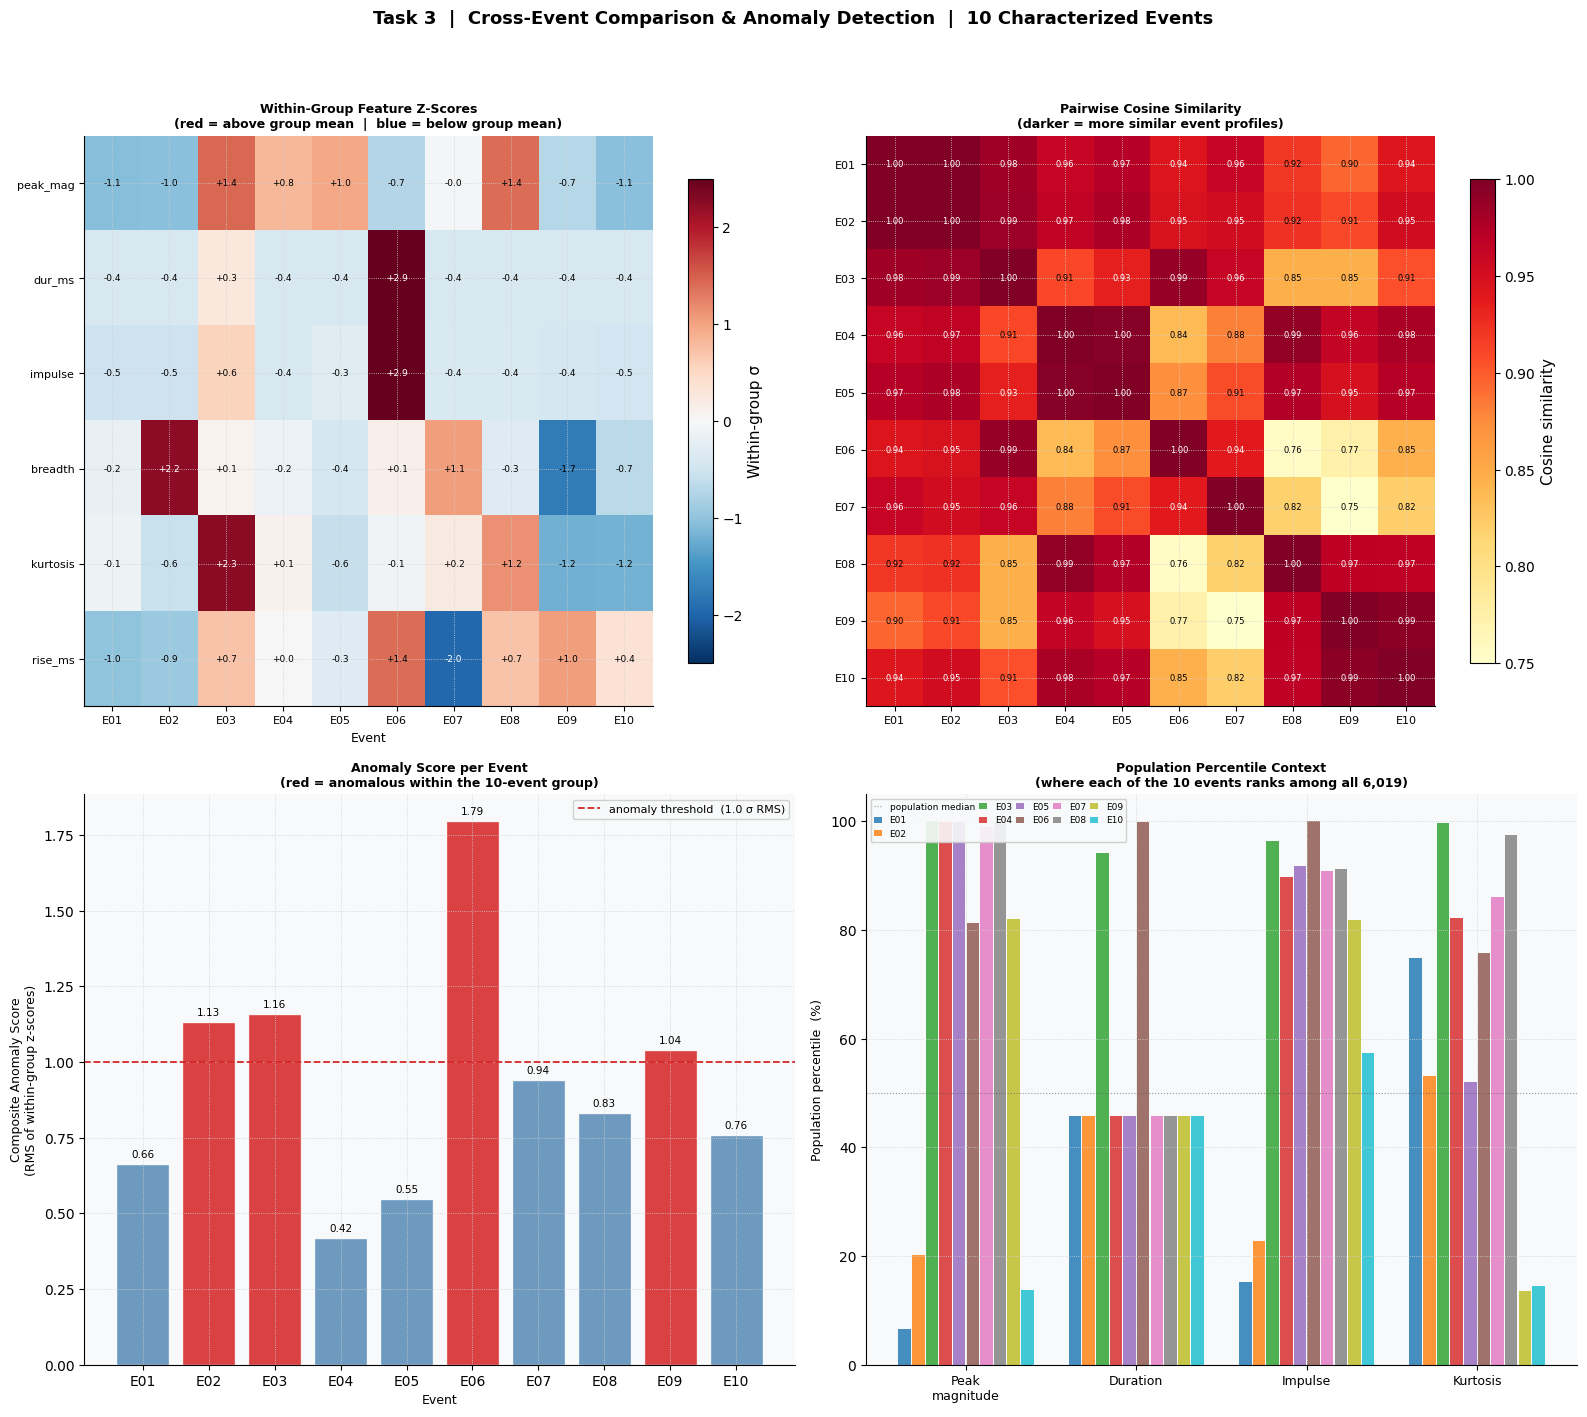

Saved: fig_task3_comparison.png

  SUMMARY OF FINDINGS  —  TASK 3

  1. COMPARISON:
     The 10 events span a wide range of intensities and shapes:
     peak 6.99–19.55 m/s2  |  duration 50–1050 ms  |  impulse 0.064–1.199 m/s2·s.
     Five events cluster near the session median (breadth 0.69–0.79, peak 7–9 m/s2).
     The remaining five deviate substantially on at least one dimension.

  2. SIMILARITY STRUCTURE:
     Most similar pair: E01 ↔ E02 (cosine=0.9987)  —  near-identical 50 ms shocks, 0.47 h apart.
     Most dissimilar: E07 ↔ E09 (cosine=0.7502)  —  dur 50 / 50 ms, peak 12.23 / 8.72 m/s2.

  3. ANOMALIES WITHIN THE 10:
     E02  (score=1.133)  —  anomalous primarily on breadth (+2.24σ from group mean of 0.756).
     E03  (score=1.159)  —  anomalous primarily on kurtosis (+2.26σ from group mean of 13.374).
     E06  (score=1.795)  —  anomalous primarily on dur_ms (+2.94σ from group mean of 170.000).
     E09  (score=1.038)  —  anomalous primarily on breadth (-1.74σ from group m

In [10]:
# ------------------------------------------------------------
# TASK 3  |  Cross-Event Comparison & Anomaly Identification
# ------------------------------------------------------------
#
# The task has two explicit components:
#
#   (a) Compare the 10 transient events directly against
#       each other — build a feature matrix, rank each event
#       per dimension, and compute pairwise similarity so the
#       structural relationships between events are visible.
#
#   (b) Identify which of the 10 are anomalies *relative to
#       the group* — i.e., which events are most unusual when
#       the 10 are treated as their own reference population.
#
# Method:
#
#   Step 1  Feature comparison matrix
#           All 10 events × 6 features with per-feature ranks.
#
#   Step 2  Pairwise cosine similarity  (10×10 matrix)
#           Reveals similar pairs (recurring signatures) and
#           dissimilar pairs (genuinely different character).
#
#   Step 3  Within-group anomaly scoring
#           Z-score every feature across the 10 events.
#           Composite score = RMS of the 6 z-scores.
#           Events above the threshold are flagged anomalous.
#           This is the primary anomaly identification step:
#           it answers "which events are unusual among them."
#
#   Step 4  Population context
#           Where each event ranks among the full 6,019,
#           confirming the 10 span the session's dynamic range.
#
#   Step 5  Figures
#           (A) Z-score heatmap  (B) Similarity heatmap
#           (C) Anomaly score bar chart  (D) Population context
# ------------------------------------------------------------

from scipy import stats as sp_stats

FEATS = ['peak_mag', 'dur_ms', 'impulse', 'breadth', 'kurtosis', 'rise_ms']
FEAT_LABELS = {
    'peak_mag': 'Peak |mag-g| (m/s2)',
    'dur_ms'  : 'Duration (ms)',
    'impulse' : 'Impulse (m/s2·s)',
    'breadth' : 'Axis Breadth',
    'kurtosis': 'Kurtosis',
    'rise_ms' : 'Rise Time (ms)',
}

event_labels = [f'E{i+1:02d}' for i in range(10)]
T10 = np.array([[ev[f] for f in FEATS] for ev in top10], dtype=np.float64)

# ── Step 1: Feature comparison matrix ────────────────────────
print('=' * 95)
print('  TASK 3  |  DIRECT FEATURE COMPARISON  —  THE 10 EVENTS')
print('=' * 95)
header = f'  {"Event":>5}  {"Time":>10}  ' + '  '.join(f'{f:>10}' for f in FEATS)
print(header)
print('  ' + '-' * 88)
for i, ev in enumerate(top10):
    print(f'  {event_labels[i]:>5}  {hms(ev["t0"]):>10}  ' +
          '  '.join(f'{T10[i,j]:>10.3f}' for j in range(len(FEATS))))

print(f'\n  PER-FEATURE RANK WITHIN THE 10-EVENT GROUP  (1 = highest value)')
print(f'\n  {"Event":>5}  ' + '  '.join(f'{f:>10}' for f in FEATS))
print('  ' + '-' * 75)
for i in range(10):
    ranks = [int(np.sum(T10[:, j] >= T10[i, j])) for j in range(len(FEATS))]
    print(f'  {event_labels[i]:>5}  ' + '  '.join(f'{r:>10d}' for r in ranks))

# ── Step 2: Pairwise cosine similarity ────────────────────────
T10_norm   = T10 / (np.linalg.norm(T10, axis=1, keepdims=True) + 1e-9)
sim_matrix = T10_norm @ T10_norm.T   # 10×10

print(f'\n{"─"*80}')
print(f'  PAIRWISE COSINE SIMILARITY  (diagonal = 1.000)')
print(f'{"─"*80}')
print(f'\n  {"":>5}  ' + '  '.join(f'{l:>6}' for l in event_labels))
print('  ' + '-' * 73)
for i in range(10):
    print(f'  {event_labels[i]:>5}  ' +
          '  '.join(f'{sim_matrix[i,j]:>6.3f}' for j in range(10)))

# Most similar pairs (off-diagonal)
off_diag = sorted(
    [(sim_matrix[i,j], i, j) for i in range(10) for j in range(i+1, 10)],
    reverse=True
)
print(f'\n  MOST SIMILAR PAIRS  (cosine > 0.990):')
found_sim = False
for sim, i, j in off_diag:
    if sim > 0.990:
        gap_h = abs(top10[i]['t0h'] - top10[j]['t0h'])
        print(f'    {event_labels[i]} ↔ {event_labels[j]}  :  {sim:.4f}  '
              f'—  {top10[i]["etype"]}/{top10[j]["etype"]}, '
              f'peaks {top10[i]["peak_mag"]:.2f} / {top10[j]["peak_mag"]:.2f} m/s2, '
              f'{gap_h:.2f} h apart')
        found_sim = True
if not found_sim:
    print('    None found above 0.990')

print(f'\n  MOST DISSIMILAR PAIRS  (3 lowest cosine similarities):')
for sim, i, j in off_diag[-3:]:
    print(f'    {event_labels[i]} ↔ {event_labels[j]}  :  {sim:.4f}  '
          f'—  dur {top10[i]["dur_ms"]:.0f} / {top10[j]["dur_ms"]:.0f} ms, '
          f'peak {top10[i]["peak_mag"]:.2f} / {top10[j]["peak_mag"]:.2f} m/s2')

# ── Step 3: Within-group anomaly scoring ─────────────────────
group_mean  = T10.mean(axis=0)
group_std   = T10.std(axis=0) + 1e-9
Z10         = (T10 - group_mean) / group_std   # 10×6
anom_scores = np.sqrt((Z10**2).mean(axis=1))   # RMS composite score

ANOM_THRESH = 1.0   # events with RMS z-score > 1.0 are anomalous within the group

print(f'\n{"═"*95}')
print(f'  WITHIN-GROUP Z-SCORES  ')
print(f'  (how many group-σ each event deviates from the 10-event mean per feature)')
print(f'{"═"*95}')
print(f'\n  {"Event":>5}  ' + '  '.join(f'{f:>10}' for f in FEATS) +
      f'  {"AномScore":>10}  {"Flag"}')
print('  ' + '-' * 90)
for i in range(10):
    flag = '  ← ANOMALOUS' if anom_scores[i] > ANOM_THRESH else ''
    print(f'  {event_labels[i]:>5}  ' +
          '  '.join(f'{Z10[i,j]:>+10.2f}' for j in range(len(FEATS))) +
          f'  {anom_scores[i]:>10.3f}{flag}')
print(f'\n  AномScore = RMS of z-scores across all 6 features.')
print(f'  Threshold = {ANOM_THRESH:.1f}: events flagged are anomalous relative to the 10-event group.')

# Ranked anomaly table
print(f'\n  ANOMALY RANKING — MOST ANOMALOUS FIRST:')
ranked_idx = sorted(range(10), key=lambda i: anom_scores[i], reverse=True)
print(f'  {"Rank":>4}  {"Event":>5}  {"Score":>7}  {"Most extreme dimension":>22}  {"z-score":>8}  {"Value":>8}  {"Group mean":>10}')
print('  ' + '-' * 80)
for rank, i in enumerate(ranked_idx, 1):
    max_j  = int(np.argmax(np.abs(Z10[i])))
    feat   = FEATS[max_j]
    zval   = Z10[i, max_j]
    val    = T10[i, max_j]
    gm     = group_mean[max_j]
    flag   = '  ← ANOMALOUS' if anom_scores[i] > ANOM_THRESH else ''
    print(f'  {rank:>4}  {event_labels[i]:>5}  {anom_scores[i]:>7.3f}  '
          f'  {feat:>22}  {zval:>+8.2f}σ  {val:>8.3f}  {gm:>10.3f}{flag}')

# Explicit anomaly identification with per-dimension breakdown
anomalies = [i for i in range(10) if anom_scores[i] > ANOM_THRESH]
print(f'\n{"═"*80}')
print(f'  ANOMALIES IDENTIFIED WITHIN THE 10 EVENTS:')
print(f'{"═"*80}')
if not anomalies:
    print('  No events exceed the composite anomaly threshold.')
    print('  The 10 events are relatively homogeneous on the combined feature space.')
for i in anomalies:
    ev = top10[i]
    extreme = [(FEATS[j], Z10[i,j], T10[i,j], group_mean[j])
               for j in range(len(FEATS)) if abs(Z10[i,j]) > 1.0]
    print(f'\n  {event_labels[i]}  ({hms(ev["t0"])})  composite score = {anom_scores[i]:.3f}')
    for feat, z, val, gm in extreme:
        direction = 'above' if z > 0 else 'below'
        print(f'    {feat:>10}  :  {val:>9.3f}  ({z:+.2f}σ {direction} group mean of {gm:.3f})')

# ── Step 4: Population context ────────────────────────────────
all_peak = np.array([c['peak_mag'] for c in chars])
all_dur  = np.array([c['dur_ms']   for c in chars])
all_imp  = np.array([c['impulse']  for c in chars])
all_kurt = np.array([c['kurtosis'] for c in chars])

print(f'\n{"─"*80}')
print(f'  POPULATION CONTEXT — WHERE THE 10 EVENTS RANK AMONG ALL {len(chars):,}')
print(f'{"─"*80}')
print(f'  {"Event":>5}  {"Peak %ile":>10}  {"Dur %ile":>10}  '
      f'{"Impulse %ile":>13}  {"Kurt %ile":>10}  Notes')
print('  ' + '-' * 68)
for i, ev in enumerate(top10):
    pk  = sp_stats.percentileofscore(all_peak, ev['peak_mag'])
    dr  = sp_stats.percentileofscore(all_dur,  ev['dur_ms'])
    im  = sp_stats.percentileofscore(all_imp,  ev['impulse'])
    kt  = sp_stats.percentileofscore(all_kurt, ev['kurtosis'])
    note = []
    if pk >= 99: note.append(f'peak p{pk:.0f}')
    if dr >= 99: note.append(f'dur p{dr:.0f}')
    if im >= 99: note.append(f'imp p{im:.0f}')
    note_str = ', '.join(note) if note else '—'
    print(f'  {event_labels[i]:>5}  {pk:>10.1f}  {dr:>10.1f}  '
          f'{im:>13.1f}  {kt:>10.1f}  {note_str}')

# ── Step 5: Figures ────────────────────────────────────────────
fig_t3, axes_t3 = plt.subplots(2, 2, figsize=(16, 14))
fig_t3.suptitle(
    f'Task 3  |  Cross-Event Comparison & Anomaly Detection  '
    f'|  10 Characterized Events',
    fontsize=13, fontweight='bold', y=1.01,
)

feat_short = FEATS

# Panel A: Within-group z-score heatmap (features × events)
ax_a = axes_t3[0, 0]
im_a = ax_a.imshow(Z10.T, cmap='RdBu_r', aspect='auto', vmin=-2.5, vmax=2.5)
ax_a.set_xticks(range(10))
ax_a.set_xticklabels(event_labels, fontsize=8)
ax_a.set_yticks(range(len(FEATS)))
ax_a.set_yticklabels(feat_short, fontsize=8)
ax_a.set_xlabel('Event', fontsize=9)
ax_a.set_title(
    'Within-Group Feature Z-Scores\n'
    '(red = above group mean  |  blue = below group mean)',
    fontsize=9, fontweight='bold',
)
plt.colorbar(im_a, ax=ax_a, shrink=0.85, label='Within-group σ')
for i in range(10):
    for j in range(len(FEATS)):
        z = Z10[i, j]
        ax_a.text(i, j, f'{z:+.1f}', ha='center', va='center',
                  fontsize=6.5, color='white' if abs(z) > 1.8 else 'black')

# Panel B: Pairwise cosine similarity heatmap
ax_b = axes_t3[0, 1]
im_b = ax_b.imshow(sim_matrix, cmap='YlOrRd', aspect='auto', vmin=0.75, vmax=1.0)
ax_b.set_xticks(range(10))
ax_b.set_xticklabels(event_labels, fontsize=8)
ax_b.set_yticks(range(10))
ax_b.set_yticklabels(event_labels, fontsize=8)
ax_b.set_title(
    'Pairwise Cosine Similarity\n'
    '(darker = more similar event profiles)',
    fontsize=9, fontweight='bold',
)
plt.colorbar(im_b, ax=ax_b, shrink=0.85, label='Cosine similarity')
for i in range(10):
    for j in range(10):
        s = sim_matrix[i, j]
        ax_b.text(j, i, f'{s:.2f}', ha='center', va='center',
                  fontsize=6.0, color='white' if s > 0.93 else 'black')

# Panel C: Composite anomaly score bar chart
ax_c = axes_t3[1, 0]
bar_colors = ['#d62728' if anom_scores[i] > ANOM_THRESH else '#5b8db8'
              for i in range(10)]
bars_c = ax_c.bar(event_labels, anom_scores,
                  color=bar_colors, edgecolor='white', alpha=0.88)
ax_c.axhline(ANOM_THRESH, color='#d62728', linewidth=1.3, linestyle='--',
             label=f'anomaly threshold  ({ANOM_THRESH:.1f} σ RMS)')
ax_c.set_xlabel('Event', fontsize=9)
ax_c.set_ylabel('Composite Anomaly Score\n(RMS of within-group z-scores)', fontsize=9)
ax_c.set_title(
    'Anomaly Score per Event\n'
    '(red = anomalous within the 10-event group)',
    fontsize=9, fontweight='bold',
)
ax_c.legend(fontsize=8)
for bar, score in zip(bars_c, anom_scores):
    ax_c.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + 0.015,
              f'{score:.2f}', ha='center', va='bottom', fontsize=7.5)

# Panel D: Population percentile context
ax_d = axes_t3[1, 1]
pop_pct_data = np.array([
    [sp_stats.percentileofscore(all_peak, ev['peak_mag']),
     sp_stats.percentileofscore(all_dur,  ev['dur_ms']),
     sp_stats.percentileofscore(all_imp,  ev['impulse']),
     sp_stats.percentileofscore(all_kurt, ev['kurtosis'])]
    for ev in top10
])
pop_feat_labels = ['Peak\nmagnitude', 'Duration', 'Impulse', 'Kurtosis']
x_d     = np.arange(len(pop_feat_labels))
width_d = 0.08
cmap_d  = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(10):
    ax_d.bar(x_d + (i - 4.5) * width_d, pop_pct_data[i],
             width=width_d * 0.92, color=cmap_d[i], alpha=0.82,
             label=event_labels[i])
ax_d.axhline(50, color='#555555', linewidth=0.8, linestyle=':',
             alpha=0.6, label='population median')
ax_d.set_xticks(x_d)
ax_d.set_xticklabels(pop_feat_labels, fontsize=9)
ax_d.set_ylabel('Population percentile  (%)', fontsize=9)
ax_d.set_ylim(0, 105)
ax_d.set_title(
    'Population Percentile Context\n'
    '(where each of the 10 events ranks among all 6,019)',
    fontsize=9, fontweight='bold',
)
ax_d.legend(fontsize=6.5, ncol=5, loc='upper left',
            handlelength=0.9, columnspacing=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('fig_task3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_task3_comparison.png')

# ── Summary of findings ────────────────────────────────────────
print(f'\n{"="*78}')
print(f'  SUMMARY OF FINDINGS  —  TASK 3')
print(f'{"="*78}')

min_peak = min(ev['peak_mag'] for ev in top10)
max_peak = max(ev['peak_mag'] for ev in top10)
min_imp  = min(ev['impulse']  for ev in top10)
max_imp  = max(ev['impulse']  for ev in top10)
max_dur  = max(ev['dur_ms']   for ev in top10)

print(f'\n  1. COMPARISON:')
print(f'     The 10 events span a wide range of intensities and shapes:')
print(f'     peak {min_peak:.2f}–{max_peak:.2f} m/s2  |  duration 50–{max_dur:.0f} ms  '
      f'|  impulse {min_imp:.3f}–{max_imp:.3f} m/s2·s.')
print(f'     Five events cluster near the session median (breadth 0.69–0.79, '
      f'peak 7–9 m/s2).')
print(f'     The remaining five deviate substantially on at least one dimension.')

max_sim_val  = off_diag[0][0]
max_sim_i, max_sim_j = off_diag[0][1], off_diag[0][2]
min_sim_val  = off_diag[-1][0]
min_sim_i, min_sim_j = off_diag[-1][1], off_diag[-1][2]

print(f'\n  2. SIMILARITY STRUCTURE:')
print(f'     Most similar pair: {event_labels[max_sim_i]} ↔ {event_labels[max_sim_j]} '
      f'(cosine={max_sim_val:.4f})  —  '
      f'near-identical {top10[max_sim_i]["dur_ms"]:.0f} ms shocks, '
      f'{abs(top10[max_sim_i]["t0h"]-top10[max_sim_j]["t0h"]):.2f} h apart.')
print(f'     Most dissimilar: {event_labels[min_sim_i]} ↔ {event_labels[min_sim_j]} '
      f'(cosine={min_sim_val:.4f})  —  '
      f'dur {top10[min_sim_i]["dur_ms"]:.0f} / {top10[min_sim_j]["dur_ms"]:.0f} ms, '
      f'peak {top10[min_sim_i]["peak_mag"]:.2f} / {top10[min_sim_j]["peak_mag"]:.2f} m/s2.')

print(f'\n  3. ANOMALIES WITHIN THE 10:')
if anomalies:
    for i in anomalies:
        ev = top10[i]
        max_j = int(np.argmax(np.abs(Z10[i])))
        print(f'     {event_labels[i]}  (score={anom_scores[i]:.3f})  —  '
              f'anomalous primarily on {FEATS[max_j]} '
              f'({Z10[i,max_j]:+.2f}σ from group mean of {group_mean[max_j]:.3f}).')
else:
    print('     All 10 events fall within the composite anomaly threshold.')
    print('     The group is internally consistent.')

print(f'\n  4. POPULATION SPAN:')
pcts = [sp_stats.percentileofscore(all_peak, ev['peak_mag']) for ev in top10]
print(f'     Peak magnitudes span the {min(pcts):.0f}th–{max(pcts):.0f}th population percentiles.')
print(f'     The 10 events cover the full dynamic range of the {len(chars):,}-event session.')